In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize and flatten
x_train = x_train.reshape(-1, 784) / 255.0
x_test = x_test.reshape(-1, 784) / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
def baseline_model():
    model = models.Sequential([
        layers.Dense(128, activation='relu', input_shape=(784,)),
        layers.Dense(64, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

In [ ]:
def dropout_model():
    model = models.Sequential([
        layers.Dense(128, activation='relu', input_shape=(784,)),
        layers.Dropout(0.5),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])
    return model

In [ ]:
def l2_model():
    model = models.Sequential([
        layers.Dense(128, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001),
                     input_shape=(784,)),
        layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(10, activation='softmax')
    ])
    return model

In [ ]:
def batchnorm_model():
    model = models.Sequential([
        layers.Dense(128, input_shape=(784,)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dense(64),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

In [ ]:
def train_model(model):
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_train, y_train,
        epochs=5,
        batch_size=128,
        validation_data=(x_test, y_test),
        verbose=1
    )

    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
    return history, test_acc

In [ ]:
history_base, acc_base = train_model(baseline_model())
history_dropout, acc_dropout = train_model(dropout_model())
history_l2, acc_l2 = train_model(l2_model())
history_bn, acc_bn = train_model(batchnorm_model())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8277 - loss: 0.5992 - val_accuracy: 0.9522 - val_loss: 0.1659
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9546 - loss: 0.1547 - val_accuracy: 0.9629 - val_loss: 0.1237
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9686 - loss: 0.1032 - val_accuracy: 0.9691 - val_loss: 0.0955
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9777 - loss: 0.0733 - val_accuracy: 0.9735 - val_loss: 0.0841
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9825 - loss: 0.0576 - val_accuracy: 0.9760 - val_loss: 0.0810
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.6094 - loss: 1.1609 - val_accuracy: 0.9326 - val_loss: 0.2328
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8887 - loss: 0.3864 - val_accuracy: 0.9478 - val_loss: 0.1703
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9137 - loss: 0.3083 - val_accuracy: 0.9577 - v

In [ ]:
print("Final Test Accuracies  :")
print("Baseline Model : ", acc_base)
print("Dropout Model : ", acc_dropout)
print("L2 Regularization Model : ", acc_l2)
print("Batch Normalization Model : ", acc_bn)

Final Test Accuracies  :
Baseline Model :  0.9760000109672546
Dropout Model :  0.9635000228881836
L2 Regularization Model :  0.9693999886512756
Batch Normalization Model :  0.9779999852180481


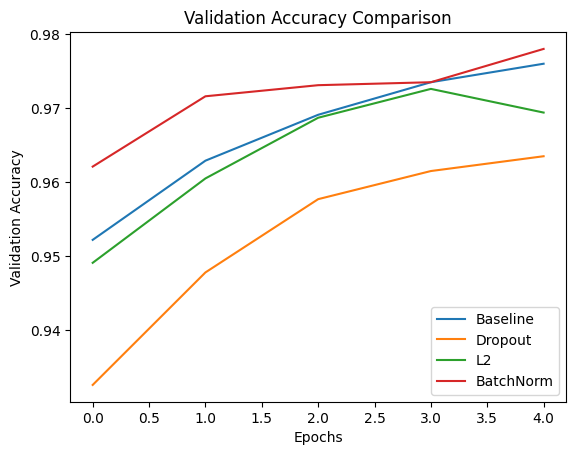

In [ ]:
plt.plot(history_base.history['val_accuracy'], label='Baseline')
plt.plot(history_dropout.history['val_accuracy'], label='Dropout')
plt.plot(history_l2.history['val_accuracy'], label='L2')
plt.plot(history_bn.history['val_accuracy'], label='BatchNorm')

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")
plt.legend()
plt.show()

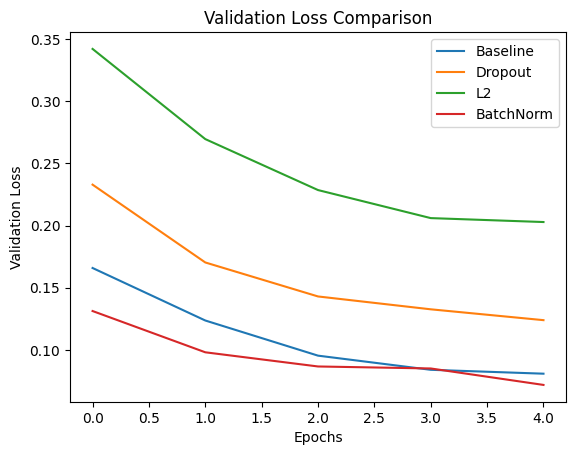

In [ ]:
plt.plot(history_base.history['val_loss'], label='Baseline')
plt.plot(history_dropout.history['val_loss'], label='Dropout')
plt.plot(history_l2.history['val_loss'], label='L2')
plt.plot(history_bn.history['val_loss'], label='BatchNorm')

plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title("Validation Loss Comparison")
plt.legend()
plt.show()

In [ ]:
accuracy_table = pd.DataFrame({
    "Model": [
        "Baseline",
        "Dropout",
        "L2 Regularization",
        "Batch Normalization"
    ],
    "Test Accuracy": [
        acc_base,
        acc_dropout,
        acc_l2,
        acc_bn
    ]
})

accuracy_table

,Model,Test Accuracy
0,Baseline,0.9760
1,Dropout,0.9635
2,L2 Regularization,0.9694
3,Batch Normalization,0.9780
